This tutorial is meant to fill a particular niche. There are lots of great flow matching/diffusion tutorials and codebases online, but you don't really need to know what an SDE is to get the main idea behind flow matching. My main goal with this document is bypass most of the complicated math and get straight to some code to simplify things.

Quick caveats:
1. The math behind flow matching and diffusion is not actually that complicated and is worth reading carefully.
2. We are still going to need some math, but nothing too onerous!

This is mostly aimed at early undergrads with some exposure to probability.

# What is generative modeling?

Generative modeling is going from noise to data. "Noise" is distributions that are easy to sample from. The normal distribution is easy to sample from; I just do `torch.randn`. The uniform distribution is also easy to sample from, and I can just do `torch.rand`. The distribution of real images is _not_ easy to sample from, but we do have a lot of pre-existing samples. Generative modeling is the task of going from this distribution that is easy to sample from to one where we have a lot of samples, but we don't necessarily have existing new samples. 

It's really important to think in terms of distributions. The details of what those distributions represent -- proteins, molecules, images, videos, audio -- are almost completely irrelevant to the way diffusion works, and generally mostly enter as far as the architecture that one chooses. You should have a picture in your mind of a distribution that's easy to sample from and a distribution defined by the data samples that we have.

In fact, let's just make some sample distributions right now. One of these will be a Gaussian, and the other will be a circle of 5 smaller Gaussians. 

In [1]:
import numpy as np
src = np.random.randn(1000,2)

centers = 6 * np.array([
    [np.cos(2*np.pi*m), np.sin(2*np.pi*m)] for m in np.linspace(0, 1, 6)
])

pts = np.random.randn(200, centers.shape[0], 2)
tgt = (centers + 0.2*pts).reshape(-1, 2)

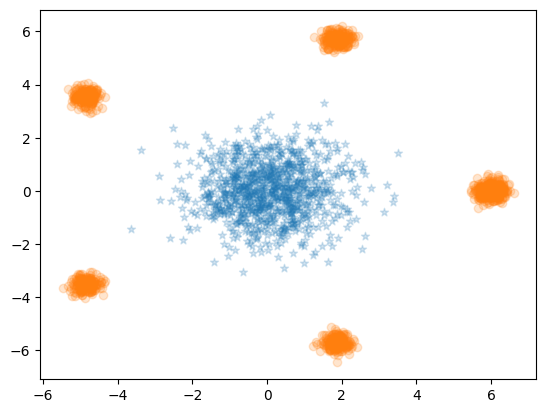

In [2]:
import matplotlib.pyplot as plt
plt.scatter(src[:, 0], src[:, 1], alpha=0.2, marker='*')
plt.scatter(tgt[:, 0], tgt[:, 1], alpha=0.2)

I know we just generated the `tgt` distribution, but imagine it's instead a distribution of images. All we have are these points. We want to train neural networks that can map between these distributions. 

# Flow matching
In flow matching, we're going to do this in an obnoxiously simple way. Let's say we want to invent a function that can just map points between the two distributions. You give me a point $x_\text{src}$ and a point $x_{\text{tgt}}$. What's the simplest way you could push one to the other? Well, in general you could imagine we might want a function
$$
f_{\theta}(x_{\text{src}}) = x_\text{tgt}
$$

The $\theta$ just means that $f$ has parameters $\theta$ (it's a neural network). There's nothing stopping us from training a neural network in this way, but in general this is quite a hard function to learn! It's much, much easier for models to learn functions where they only change a little bit at a time. If you are familiar with language models, consider that predicting the next two or three tokens is generally much harder than just predicting the single next token. These principles are actually quite similar.

If we want to just predict a small change, we're going to need to plot out where we want to go and slice it up into a sequence of small changes. Then we can train our model to predict each of those tiny changes. In that spirit, let's ask again: what's the simplest path we could take between points from these two distributions? There are many, but the easiest might simply be to linearly interpolate. That is, we do

$$
x_t = (1-t) x_\text{src} + t x_\text{tgt}\qquad t\in[0,1]
$$

Let's unpack this a bit. At $t=0$, $x_{t=0}$ is the source data. At $t=1$, $x_{t=1}$ is the target data. At intermediate points, we're just plotting a straight line between the two points. In theory, you can use any "path" as long as at the start it's $x_{\text{src}}$ and at the end it's $x_{\text{tgt}}$, but this one's quite simple. Let's pick two points and plot this path now.

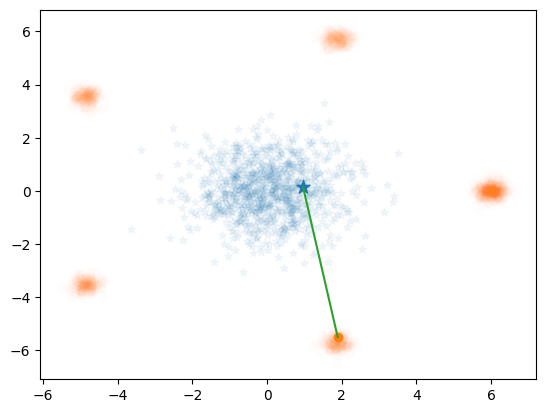

In [3]:
plt.scatter(src[:, 0], src[:, 1], alpha=0.05, marker='*')
plt.scatter(tgt[:, 0], tgt[:, 1], alpha=0.01)

IDX = 100 # random point

plt.scatter(src[IDX, 0], src[IDX, 1], alpha=1, marker='*', c='C0', s=100)
plt.scatter(tgt[IDX, 0], tgt[IDX, 1], marker='o', c='C1')

t = np.linspace(0, 1, 100)[:, None]
pts = src[IDX] * t + (1-t) * tgt[IDX]

plt.plot(
    pts[:, 0], pts[:, 1], c='C2'
)

The path is in green, and it maps points from the source to the target distribution. Our goal is going to be to train a model that can "walk" us down the path. To do the actual walking, we're going to repeatedly do 

$$
x_{t+\Delta t} = \tilde{f}_{\theta}(x_t, t)
$$

In other words, our neural network accepts the _emph_ current position along time and returns the _next_ position along time. If we repeat this a bunch of times, we get $x_{\text{tgt}}$.

Let's remind ourselves: our goal is to generate new samples from a distribution that's hard to sample. So in practice, what we'll be doing is drawing samples from our easy to sample Gaussian, calling that $x_0$, then passing it through the above neural network as it slowly gets transformed into a sample from our desired distribution.

One last, slightly subtle point. It is hopefully intuitive that the task gets easier when the size of each step is small, but this isn't free. If the size of a step is small, we need _more_ steps to get to the desired final location. We've written this in a very general way above, since we just said the time varied between 0 and 1, but in practice we need to take a finite number of steps. There may be times when I have more computing power, so I'm willing to take more steps to get a more accurate reading, while other times I may want to take fewer steps so I get a sample faster. As I've written the network above, **I can't do this**. During inference, I'll have a fixed number of steps that I trained against. To get this capability, one thing we can do instead is write 


$$
x_{t+\Delta t} = \tilde{f}_{\theta}(x_t, t) \Rightarrow x_{t+\Delta t} = x_t + \tilde{v}_{\theta}(x_t, t)\Delta t
$$

Notice I haven't changed much; instead of telling me exactly where to go, my model just tells me the general direction and I manually take a step in that direction outside of the model. I can now take however many steps I want during inference. It turns out there's actually several reasons to prefer the second formulation. It's anecdotally a bit easier to train (we're estimating a local property instead of a more global property), it substantially simplifies our objective functions, and it has some very elegant associations with physics (the equation above looks a lot like the simple equations of motion you learn in an introductory physics course). Largely because of the latter point, this also lets us use highly optimized numerical solvers to generate samples, which is something I'll touch on later.


(If you're interested, we've formulated this problem as a neural ODE. This was a big step for diffusion models as well; instead of a finite number of diffusion steps, the diffusion approach was formulated as a continuous-time stochastic differential equation)

## How to train a flow matching model

I've just argued that you should train a model to predict the direction along a path so you can take a step in that direction during inference. We'll now discuss how we actually train this model.

First, what's the direction we should be moving in? It's actually pretty simple. Remember our previously parameterized expression for $x_t$? What we want is just $d x_t/dt$, which is

$$
\frac{d}{dt}x_t = (1-t) x_\text{src} + t x_\text{tgt} = x_\text{tgt} - x_{\text{src}}
$$

That's it! You don't even really need derivatives to see this. You can just note that this is a straight line and try to construct the rise over the run with respect to time. Let's try to keep our tensor shapes in mind. $x_t$ has some arbitrary shape $[D]$, so its derivative with respect to $t$ also has shape $[D]$. Our expression above agrees with this.

To train this thing, we'll just use an MSE loss. 

$$
L_{FM} = \Vert f_{\theta}(x_t, t) - (x_\text{tgt} - x_{\text{src}}\Vert^2
$$

That's it! There's more to say on flow matching, but now let's dive into some simple code. 

## Our first baby flow matching model 

In [4]:
import torch
import torch.nn as nn
import math
class TimestepEmbedder(nn.Module):
    """
    We don't worry too much about what this is doing! It's giving us a simple way to represent $t$
    """
    def __init__(self, hidden_size, frequency_embedding_size=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(frequency_embedding_size, hidden_size, bias=True),
            nn.SiLU(),
            nn.Linear(hidden_size, hidden_size, bias=True),
        )
        self.frequency_embedding_size = frequency_embedding_size

    @staticmethod
    def timestep_embedding(t, dim, max_period=10000):

        half = dim // 2
        freqs = torch.exp(
            -math.log(max_period) * torch.arange(start=0, end=half, dtype=torch.float32) / half
        ).to(device=t.device)
        args = t[:, None].float() * freqs[None]
        embedding = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
        return embedding

    def forward(self, t):
        t_freq = self.timestep_embedding(t, self.frequency_embedding_size)
        t_emb = self.mlp(t_freq)
        return t_emb

class FlowMatcher(nn.Module):
    def __init__(self, dim_in, dim_hidden):
        super().__init__()
        self.up = nn.Linear(dim_in, dim_hidden)
        self.net = nn.ModuleList([
            nn.Sequential(
                nn.Linear(dim_hidden, 4*dim_hidden),
                nn.SiLU(),
                nn.Linear(4*dim_hidden, dim_hidden)
            ) for _ in range(4)
        ])
        self.time_embed = TimestepEmbedder(dim_hidden)
        self.down = nn.Linear(dim_hidden, dim_in)

    def _forward(self, x_t, t):
        h = self.up(x_t) + self.time_embed(t)
        for block in self.net:
            h = h + block(h)
        v = self.down(h)
        return v

    def forward(self, x_src, x_tgt, t):
        x_t = t.unsqueeze(-1) * x_tgt + (1-t).unsqueeze(-1) * x_src
        v = self._forward(x_t, t)
        
        u = x_tgt - x_src
        loss = ((v - u) ** 2).mean()
        return v, loss

In [30]:
# now let's make a training loop

src = np.random.randn(1000,2)

centers = 6 * np.array([
    [np.cos(2*np.pi*m), np.sin(2*np.pi*m)] for m in np.linspace(0, 1, 6)[:-1]
])

pts = np.random.randn(1_000, centers.shape[0], 2)
tgt = (centers + 0.2*pts).reshape(-1, 2)
tgt = torch.from_numpy(tgt).to(torch.float32)

In [31]:
from tqdm.auto import tqdm

net = FlowMatcher(2, 256)
bsz = 64
losses = []

optim = torch.optim.Adam(net.parameters(), lr=3.e-4)

for _ in tqdm(range(2_000)):
    idx = torch.rand(tgt.size(0),).argsort()[:bsz]

    x_tgt = tgt[idx]
    x_src = torch.randn_like(x_tgt) # note what we're doing here!
    t = torch.rand(bsz, dtype=torch.float32)

    _, loss = net(x_src, x_tgt, t)
    loss.backward()
    optim.step()
    optim.zero_grad(set_to_none=True)

    losses.append(loss.item())

  0%|          | 0/2000 [00:00<?, ?it/s]

In [32]:
# now let's try sampling
import time
@torch.no_grad()
def sample(model, shape, n_steps=100):
    x = torch.randn(*shape, dtype=torch.float32)
    ts = torch.linspace(0, 1, n_steps)
    dt = ts[1] - ts[0]
    for t_ in ts:
        t = torch.ones((x.shape[0],), dtype=torch.float32) * t_
        v = model._forward(x, t)
        x = x + dt * v
    return x

In [33]:
samples = sample(net, (256, 2), n_steps=1000).numpy()

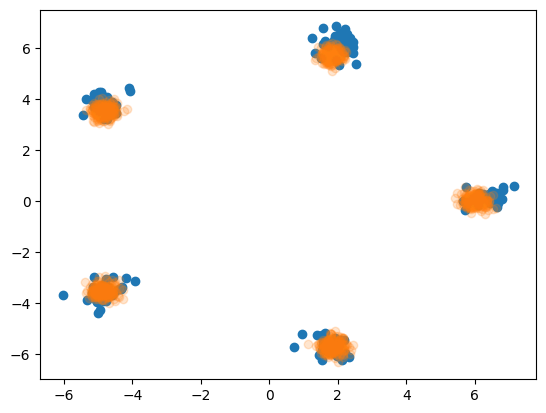

In [34]:
plt.scatter(samples[:, 0], samples[:, 1])
plt.scatter(tgt[:1000, 0], tgt[:1000, 1], alpha=0.2)

## Analyzing our flow matcher

That's it! You can see this produced data from our sample distribution. If this seems unimpressive to you, consider that this same simple technique is basically at the heart of every single modern generative model, from those fancy video generation models like Sora to the image generation models on ChatGPT. There are many ways we can make this model better, but for now let's make a few observations.

First, let's take a look at the paths that we actually trace out. We'll adjust our sampling function for this.

In [35]:
@torch.no_grad()
def sample_with_paths(model, shape, n_steps=100):
    x = torch.randn(*shape, dtype=torch.float32)
    ts = torch.linspace(0, 1, n_steps)
    dt = ts[1] - ts[0]
    path = []
    for t_ in ts:
        path.append(x.clone())
        t = torch.ones((x.shape[0],), dtype=torch.float32) * t_
        v = model._forward(x, t)
        x = x + dt * v
    path.append(x)
    return np.array(path), x

In [36]:
path, samples = sample_with_paths(net, (256, 2), n_steps=100)

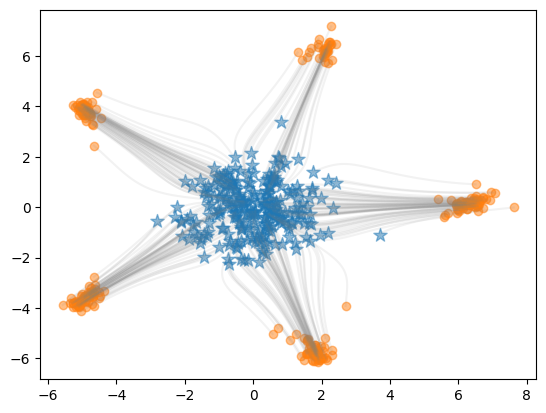

In [37]:
# plot first step
plt.scatter(*path[0].T, marker='*', s=100, alpha=0.5)

# plot intermediate times
for m in range(path.shape[1]):
    pth = path[:, m, :] 
    plt.plot(pth[:, 0], pth[:, 1], alpha=0.1, c='gray')
    
# plot last step
plt.scatter(*path[-1].T, alpha=0.5)

You can see that these paths aren't straight, they're actually a bit curved! We trained against straight paths. Why? In fact, we trained against straight paths to a particular target sample, but at a particular point $x_t$, there may be many possible target samples. What we train against is really a sort of average over all these possible paths. This effect is stronger at the start in our example, since many of these paths are crossing. As we get closer to our destination, we have fewer of these crossings and our paths tend to get straighter. 

A point worth emphasizing is that the only restriction on our model was that the input and output dimensions are the same. This requirement is because the model represents $v_t = d x_t/ dt$, which has the same dimensionality as $x$. But it doesn't matter whether our model is a transformer, an MLP, or even something more exotic. As long as the inputs and outputs are the same, everything will be fine. 

## Conditioning
We're generally not interested in just sampling randomly from a distribution; we often want to sample subject to certain constraints. This is called conditioning. From a machine learning perspective, we just need our model to have access to the conditioning information. There are many ways to do this (this is sort of architectural in nature), but as a starting point, we'll train a small model that just conditions based on which of the five point clouds we want to generate.

In [38]:

class ConditionalFlowMatcher(nn.Module):
    def __init__(self, dim_in, dim_hidden, n_classes):
        super().__init__()
        self.up = nn.Linear(dim_in, dim_hidden)
        self.class_embed = nn.Embedding(n_classes, dim_hidden)
        self.net = nn.ModuleList([
            nn.Sequential(
                nn.Linear(dim_hidden, 4*dim_hidden),
                nn.SiLU(),
                nn.Linear(4*dim_hidden, dim_hidden)
            ) for _ in range(4)
        ])
        self.time_embed = TimestepEmbedder(dim_hidden)
        self.down = nn.Linear(dim_hidden, dim_in)

    def _forward(self, x_t, t, classes):
        h = self.up(x_t) + self.time_embed(t) + self.class_embed(classes)
        for block in self.net:
            h = h + block(h)
        v = self.down(h)
        return v

    def forward(self, x_src, x_tgt, t, classes):
        x_t = t.unsqueeze(-1) * x_tgt + (1-t).unsqueeze(-1) * x_src
        v = self._forward(x_t, t, classes)
        
        u = x_tgt - x_src
        loss = ((v - u) ** 2).mean()
        return v, loss

In [57]:
# remake dataset with class information

src = np.random.randn(1000,2)

centers = 6 * np.array([
    [np.cos(2*np.pi*m), np.sin(2*np.pi*m)] for m in np.linspace(0, 1, 6)[:-1]
])

pts = np.random.randn(1_000, centers.shape[0], 2)
tgt = (centers + 0.2*pts).reshape(-1, 2)
tgt = torch.from_numpy(tgt).to(torch.float32)
classes = (torch.arange(5).unsqueeze(0).repeat(1000, 1, 1)).reshape(-1,)

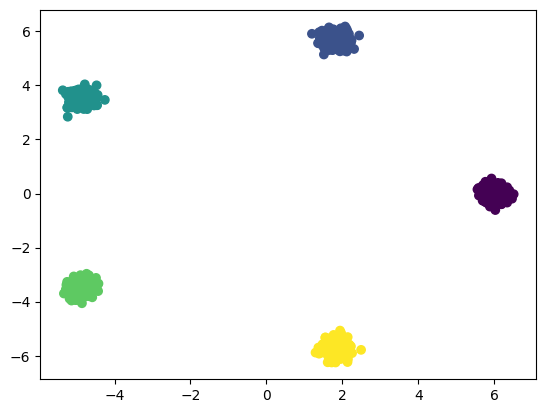

In [60]:
# double check our classes are correct
c = classes[idx]
p = tgt[idx]
plt.scatter(p[:, 0], p[:, 1], c=c)

In [61]:
from tqdm.auto import tqdm

net = ConditionalFlowMatcher(2, 256, n_classes=6)
bsz = 64
losses = []

optim = torch.optim.Adam(net.parameters(), lr=3.e-4)

for _ in tqdm(range(2_000)):
    idx = torch.rand(tgt.size(0),).argsort()[:bsz]

    x_tgt = tgt[idx]
    x_src = torch.randn_like(x_tgt) # note what we're doing here!
    t = torch.rand(bsz, dtype=torch.float32)
    c = classes[idx]

    _, loss = net(x_src, x_tgt, t, c)
    loss.backward()
    optim.step()
    optim.zero_grad(set_to_none=True)

    losses.append(loss.item())

  0%|          | 0/2000 [00:00<?, ?it/s]

In [62]:
# Now we'll just sample two classes
# now let's try sampling
@torch.no_grad()
def sample_conditional(model, shape, n_steps=100):
    x = torch.randn(*shape, dtype=torch.float32)
    c = torch.zeros(*shape[:-1], dtype=torch.long)
    c[c.size(0)//2:] = 2
    ts = torch.linspace(0, 1, n_steps)
    dt = ts[1] - ts[0]
    for t_ in ts:
        t = torch.ones((x.shape[0],), dtype=torch.float32) * t_
        v = model._forward(x, t, c)
        x = x + dt * v
    return x

In [63]:
samples = sample_conditional(net, (256, 2), n_steps=1000).numpy()

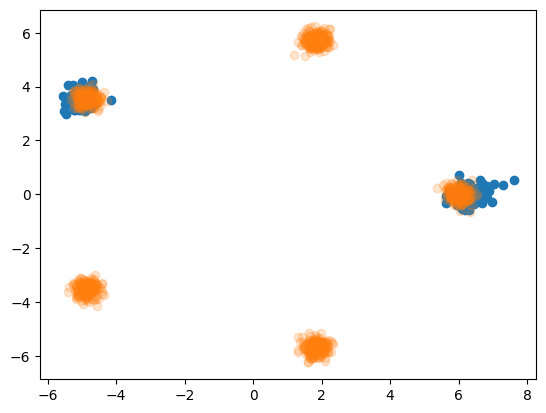

In [65]:
plt.scatter(samples[:, 0], samples[:, 1])
plt.scatter(tgt[:1000, 0], tgt[:1000, 1], alpha=0.2)

Our classes are very simple, so we can have very simple conditioning. For more complex conditioning (like conditioning based on a sequence), we'll need to work a bit harder. More on that later!